In [6]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from tqdm import tqdm

  0%|                                                                                         | 0/1000 [00:00<?, ?it/s]

100%|██████████████████████████████████████████████████████████████████████████████| 1000/1000 [01:36<00:00, 10.32it/s]


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step


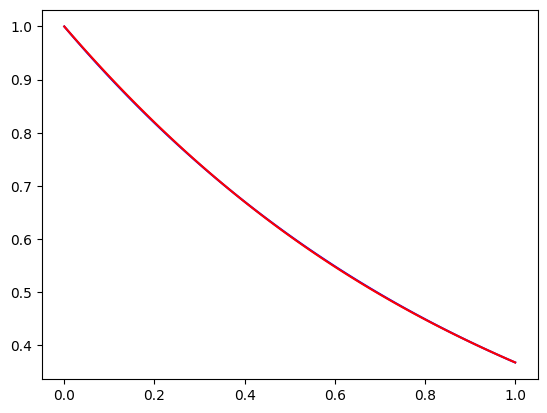

In [7]:
model = Sequential([
    Dense(50, activation='tanh', input_shape=(1,)),
    Dense(50, activation='tanh'),
    Dense(1)
])
adam = Adam(learning_rate=0.01)

def train_step(t):
    with tf.GradientTape(persistent=True) as tape:
        tape.watch(t)
        N = 1.0 + t * model(t)
        dN_dt = tape.gradient(N,t)
        loss = tf.reduce_mean(tf.square(dN_dt + N))
    gradients = tape.gradient(loss, model.trainable_variables)
    adam.apply_gradients(zip(gradients, model.trainable_variables))
    return loss
    
t_data = tf.cast(np.linspace(0,1,100).reshape(-1,1), tf.float32)
epochs = 1000
loss_val = np.zeros(epochs)
for e in tqdm(range(epochs)):
    loss_val[e] = train_step(t_data)
    
t_test = np.linspace(0,1,100).reshape(-1,1)
N_pred = 1.0 + t_test*model.predict(t_test)
N_exact = np.exp(-t_test)

plt.plot(t_test, N_exact, 'b')
plt.plot(t_test, N_pred, 'r')
plt.show()

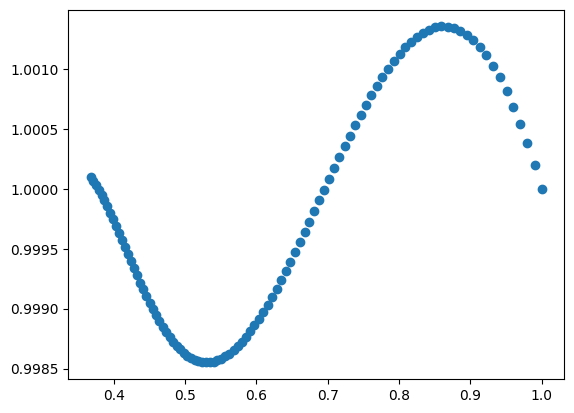

In [12]:
plt.scatter(N_exact, N_pred/N_exact)
plt.show()